In [1]:
import torch

from utils.checkpoints import load_ae_from_path, load_cspn_from_path
from visualisation import show
from pathlib import Path


In [2]:
ae_path = Path("../checkpoints/autoencoder/flowers.pt")
ae = load_ae_from_path(ae_path)

In [3]:
cspn_spf_path = Path("../checkpoints/cspn/flowers_spflow.pt")
cspn_spf = load_cspn_from_path(cspn_spf_path)

In [4]:
cspn_custom_path = Path("../checkpoints/cspn/flowers_custom.pt")
cspn_custom = load_cspn_from_path(cspn_custom_path)


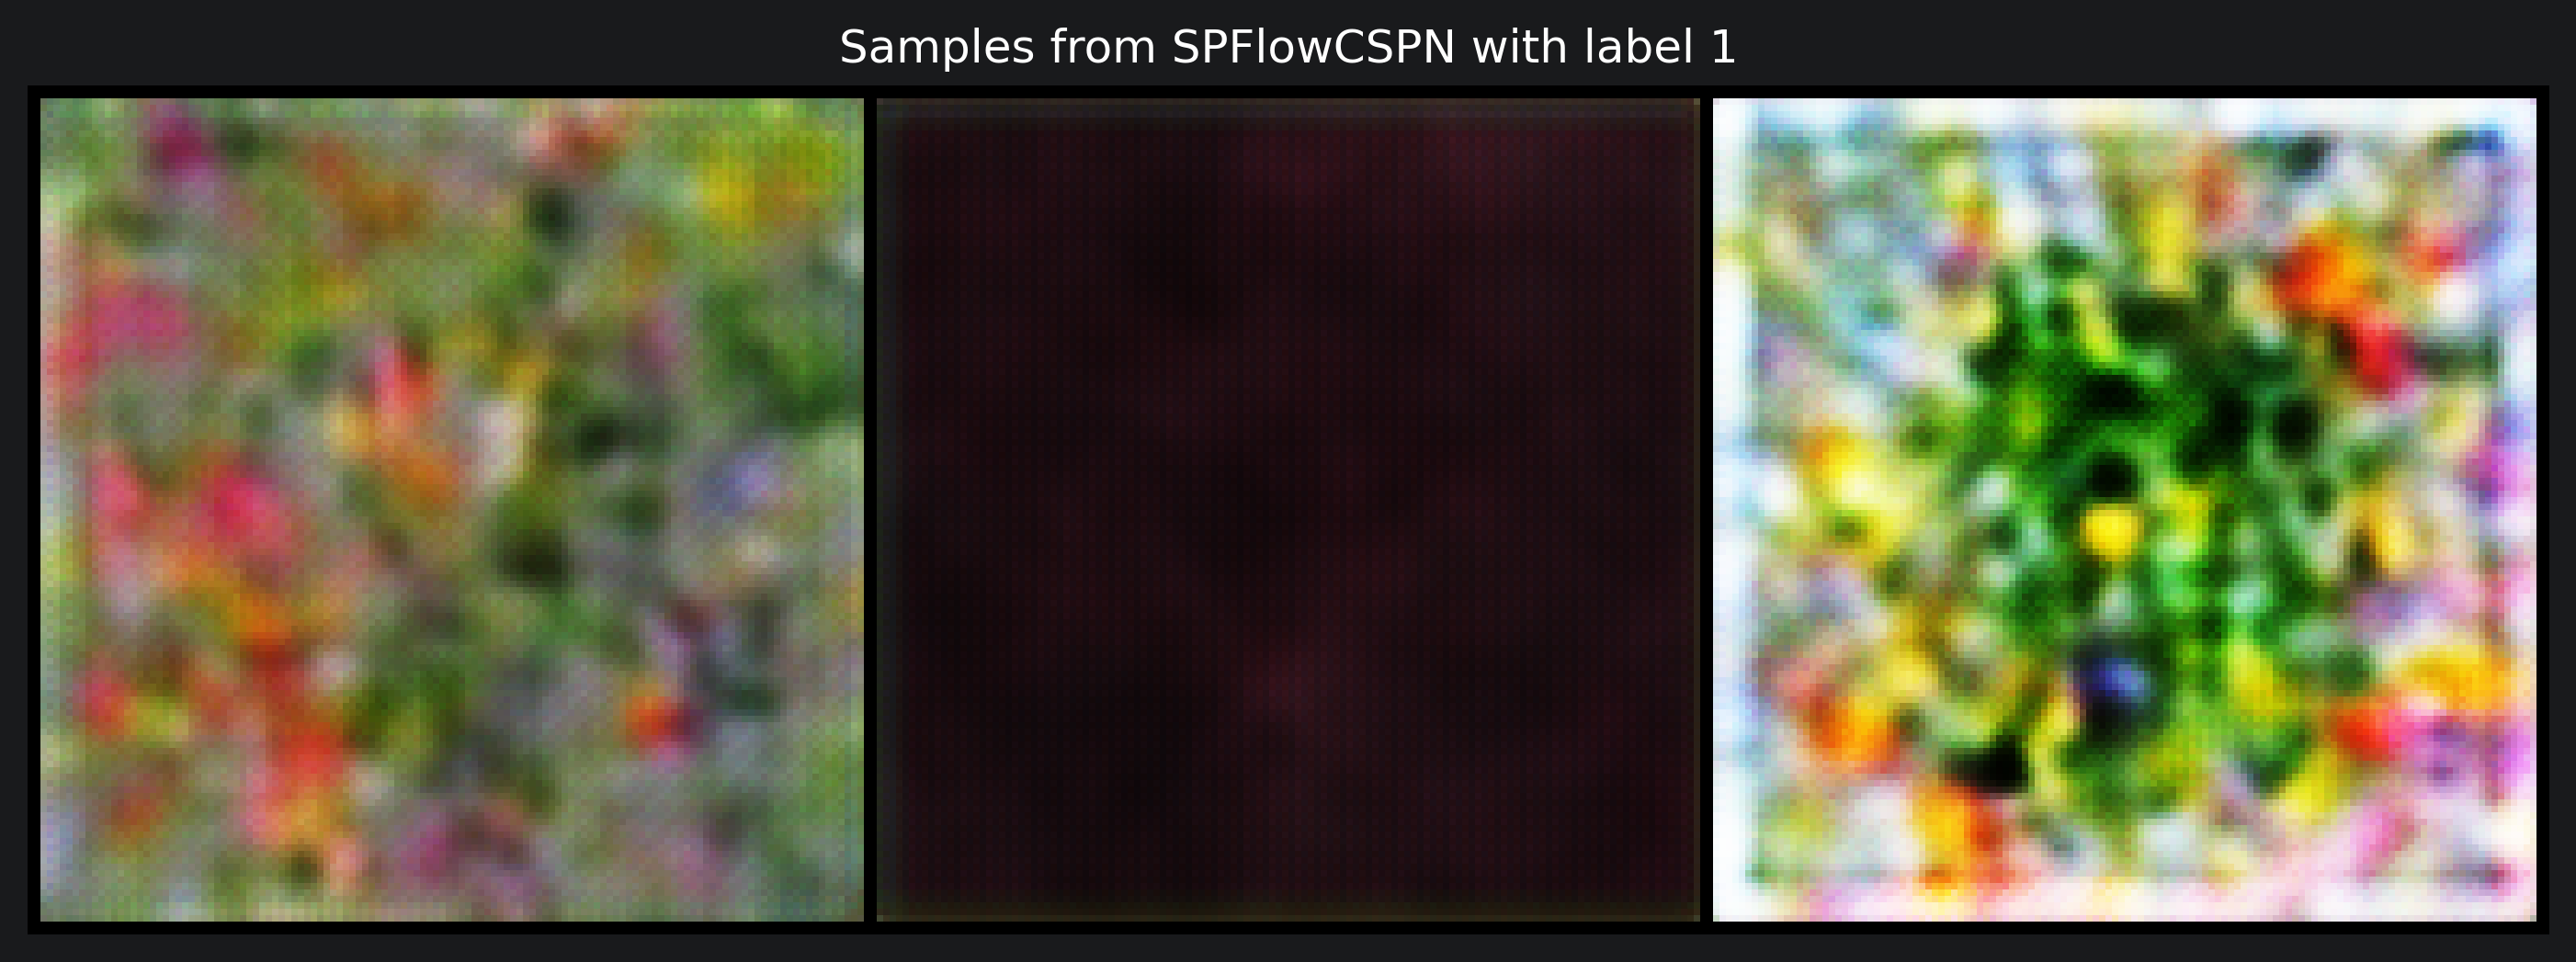

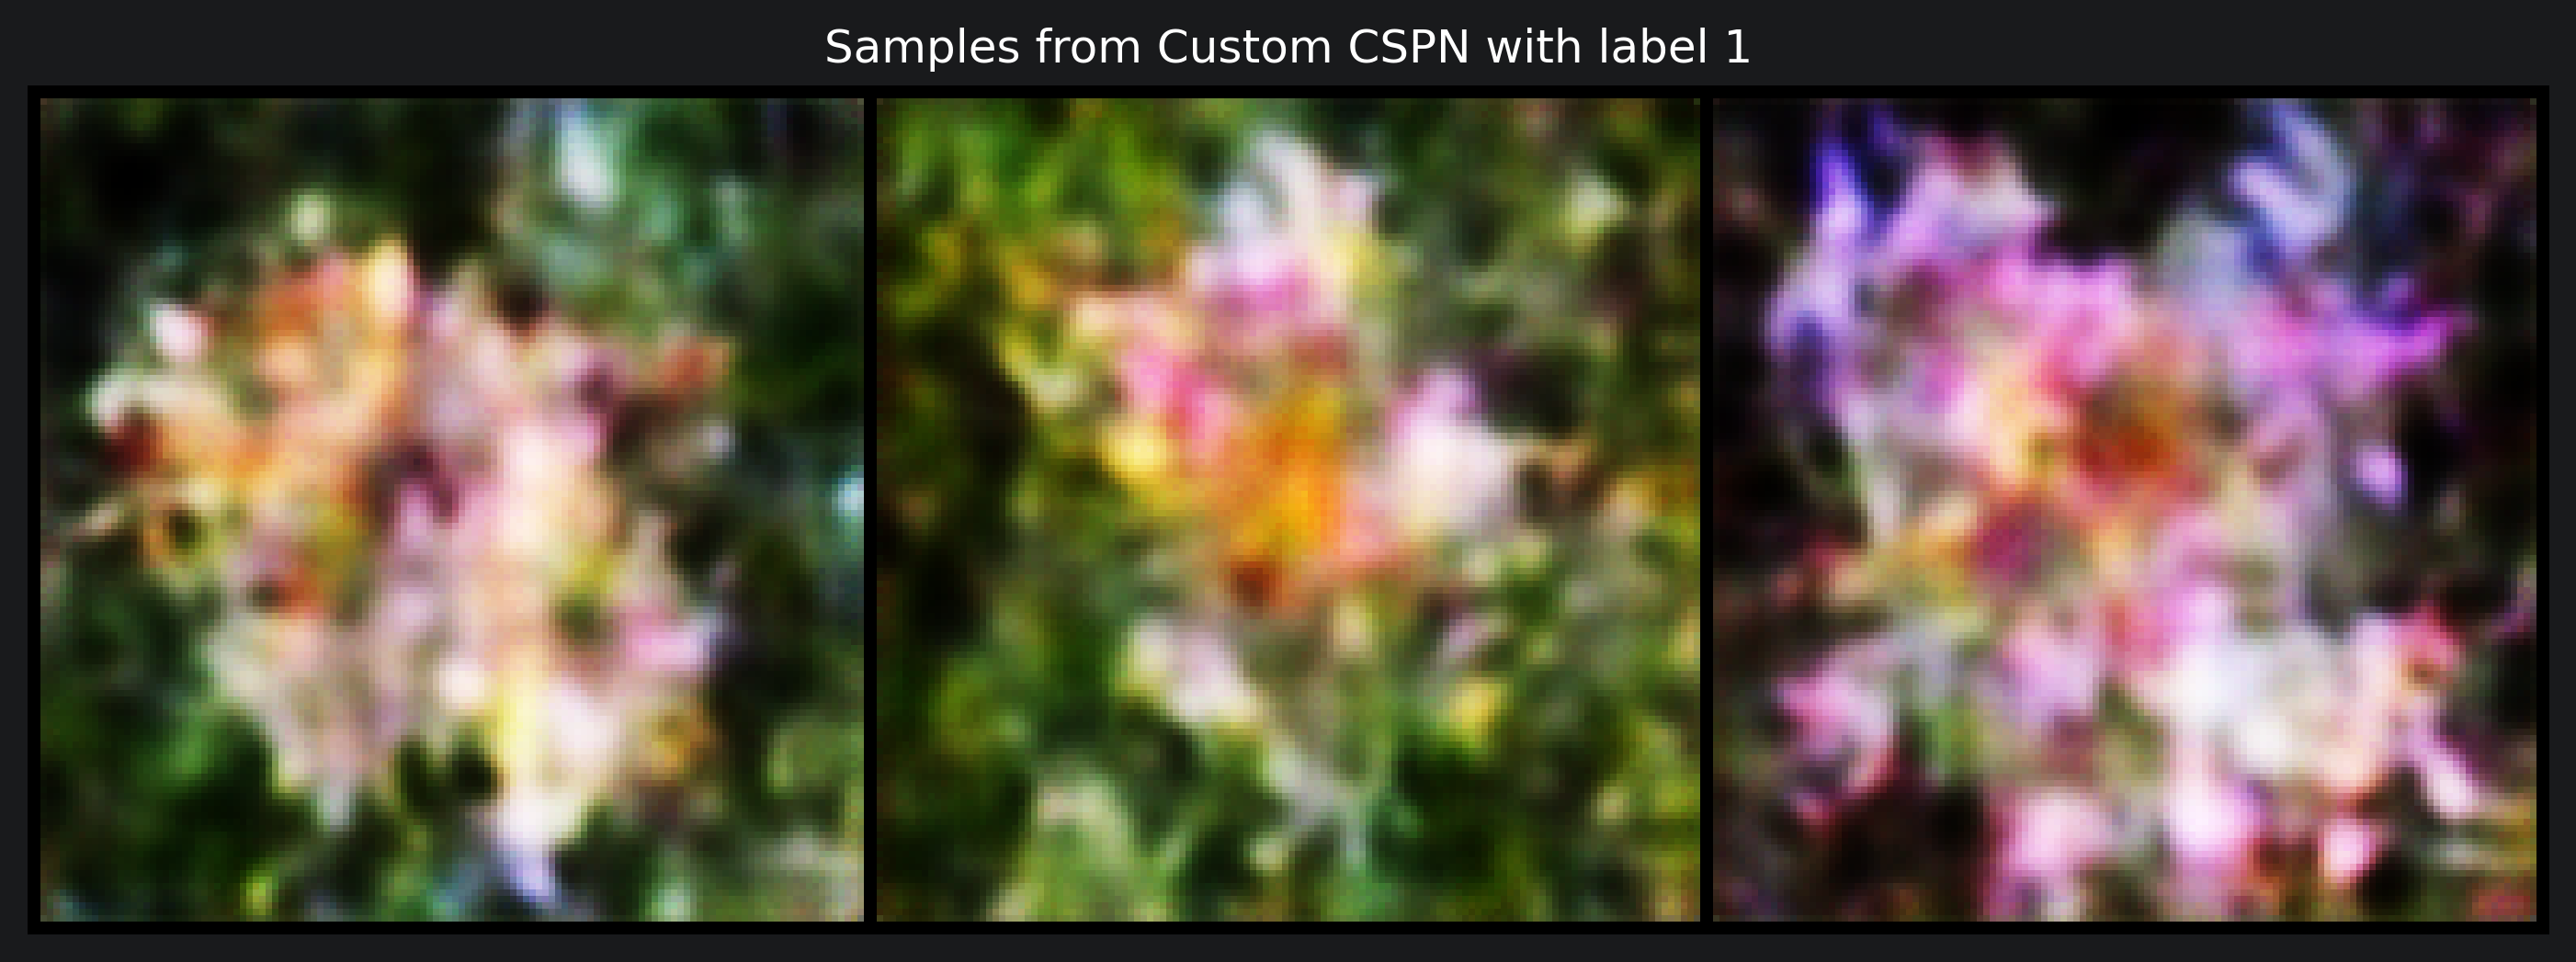

In [5]:
label = 1
sample_labels = torch.tensor([label] * 3)

with torch.no_grad():
    samples_spf = cspn_spf.sample(sample_labels)
    sampled_images_spf = ae.decode(samples_spf)
    samples_custom = cspn_custom.sample(sample_labels)
    sampled_images_custom = ae.decode(samples_custom)

show(sampled_images_spf, f"Samples from SPFlowCSPN with label {label}")
show(sampled_images_custom, f"Samples from Custom CSPN with label {label}")

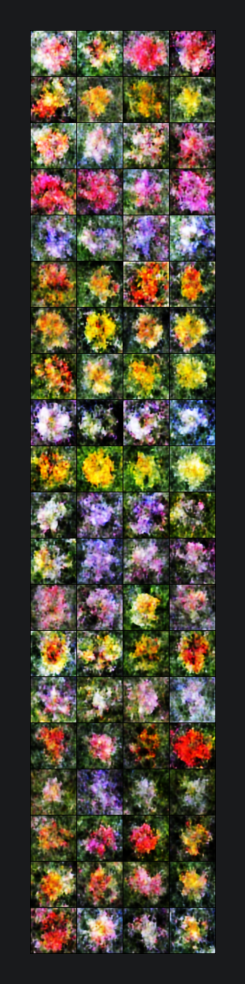

In [9]:
all_labels = torch.arange(40, 60).repeat_interleave(4)

with torch.no_grad():
    samples = cspn_custom.sample(all_labels)
    sampled_images = ae.decode(samples)

show(sampled_images, width=4)